# Análise de Inadimplência em Carteira de Crédito
## Etapa 2 — Análise Exploratória de Dados (EDA)

**Objetivo:** Responder perguntas de negócio usando visualizações e estatísticas.  
**Input:** `dados_limpos.csv` (gerado na Etapa 1)

---

### Perguntas que vamos responder

1. Qual o perfil demográfico dos clientes inadimplentes?
2. Histórico de atrasos tem relação com inadimplência futura?
3. Renda e uso do crédito rotativo influenciam o risco?
4. Quais variáveis têm mais poder preditivo?

> Em um projeto real, essas perguntas viriam do cliente (banco/financeira). Aqui, estamos simulando esse papel.

## 0. Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

# Paleta de cores consistente com o tema do projeto
COR_ADIMPLENTE   = '#3B8BD4'   # azul — situação normal
COR_INADIMPLENTE = '#E85D24'   # laranja-vermelho — risco
PALETTE = [COR_ADIMPLENTE, COR_INADIMPLENTE]

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False


import os
os.makedirs('figuras', exist_ok=True)
print('Setup concluído.')

Setup concluído.


In [20]:
df = pd.read_csv('dados_limpos.csv')

# Garantir que faixa_etaria seja categórica ordenada
ordem_faixas = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['faixa_etaria'] = pd.Categorical(df['faixa_etaria'], categories=ordem_faixas, ordered=True)

# Separar grupos para comparações diretas
inadimplentes = df[df['target'] == 1]
adimplentes   = df[df['target'] == 0]

print(f'Dataset: {len(df):,} clientes — {len(inadimplentes):,} inadimplentes ({df["target"].mean()*100:.1f}%)')

Dataset: 149,999 clientes — 10,026 inadimplentes (6.7%)


---
## Pergunta 1: Qual o perfil demográfico dos clientes inadimplentes?

Vamos começar com a variável mais básica: **idade**.

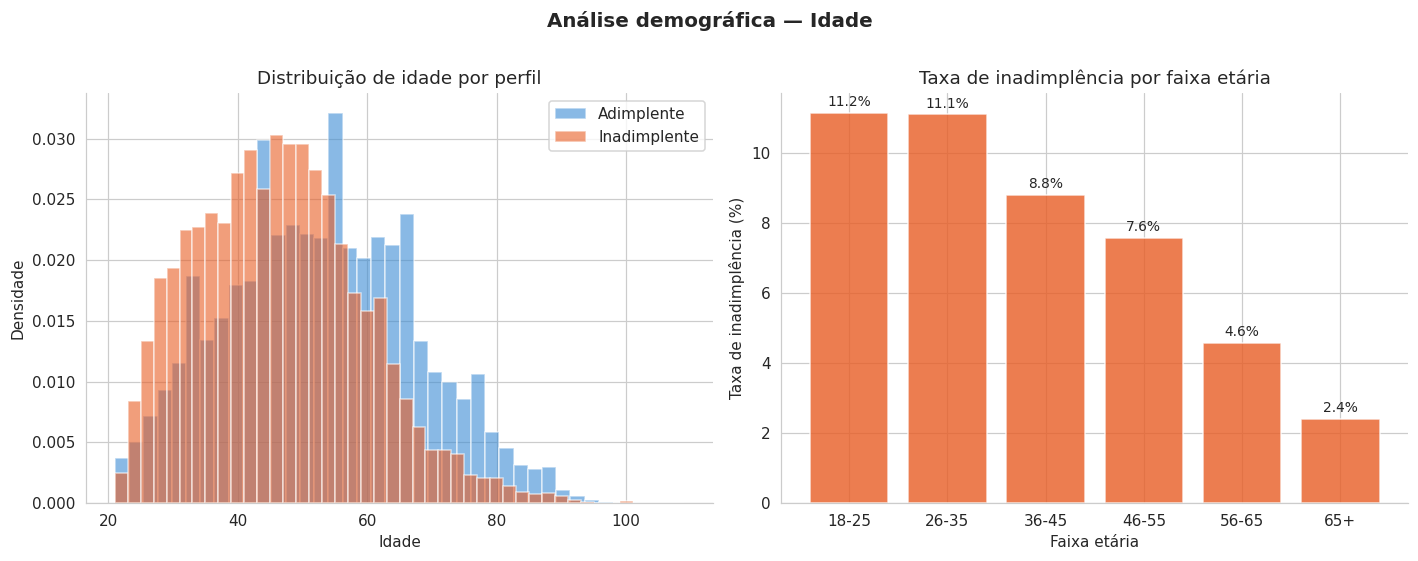

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Distribuição de idade por grupo --
ax = axes[0]
for label, grupo, cor in [('Adimplente', adimplentes, COR_ADIMPLENTE),
                            ('Inadimplente', inadimplentes, COR_INADIMPLENTE)]:
    ax.hist(grupo['idade'], bins=40, alpha=0.6, color=cor, label=label, density=True)
ax.set_xlabel('Idade')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição de idade por perfil')
ax.legend()

# -- Taxa de inadimplência por faixa etária --
ax = axes[1]
taxa_por_faixa = df.groupby('faixa_etaria', observed=True)['target'].mean() * 100
bars = ax.bar(taxa_por_faixa.index, taxa_por_faixa.values, color=COR_INADIMPLENTE, alpha=0.8)
ax.set_xlabel('Faixa etária')
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_title('Taxa de inadimplência por faixa etária')
for bar, val in zip(bars, taxa_por_faixa.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Análise demográfica — Idade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figuras/fig_01_idade.png', bbox_inches='tight', dpi=120)
plt.show()

In [22]:
# Estatísticas descritivas de idade por grupo
resumo_idade = df.groupby('target')['idade'].describe().round(1)
resumo_idade.index = ['Adimplente', 'Inadimplente']
print('Estatísticas de idade por grupo:')
resumo_idade

Estatísticas de idade por grupo:


,count,mean,std,min,25%,50%,75%,max
Adimplente,139973.00,52.80,14.80,21.00,42.00,52.00,63.00,109.00
Inadimplente,10026.00,45.90,12.90,21.00,36.00,45.00,54.00,101.00


**💡 Insight de negócio:** Clientes mais jovens (18–35 anos) apresentam taxa de inadimplência significativamente maior. Isso pode indicar menor estabilidade financeira ou menor histórico de crédito. Políticas de concessão diferenciadas por faixa etária podem ser relevantes.

---
## Pergunta 2: Histórico de atrasos tem relação com inadimplência futura?

Intuitivamente, quem já atrasou antes tem mais chance de atrasar novamente. Vamos quantificar isso.

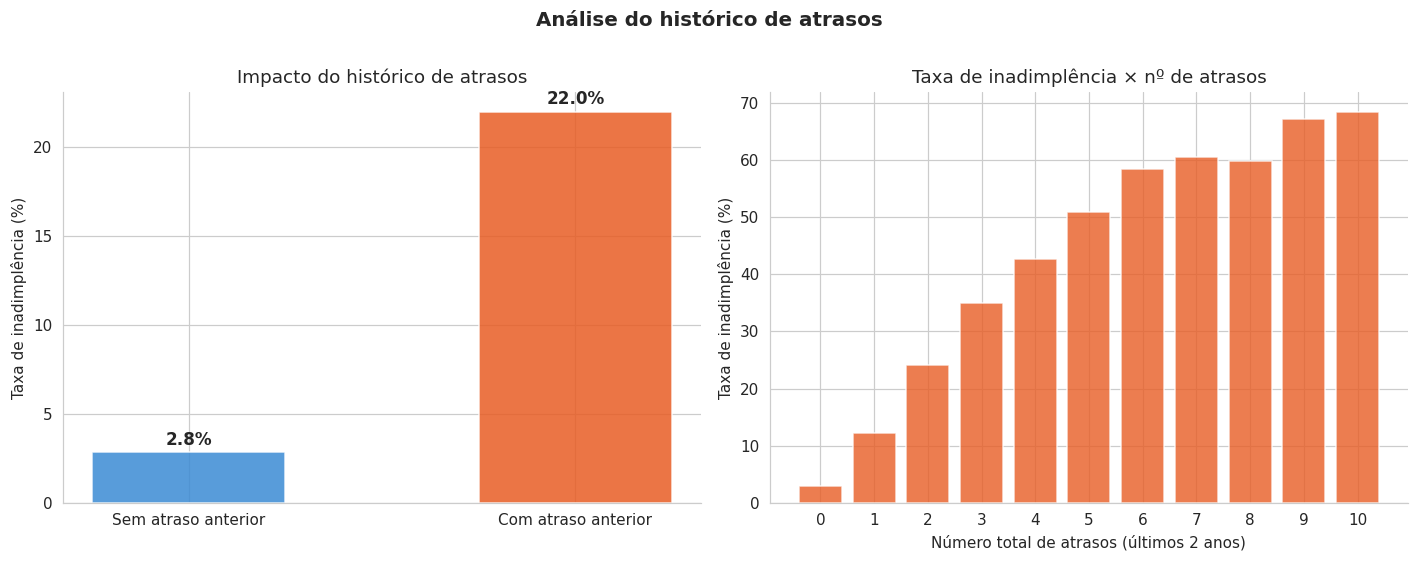

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Taxa de inadimplência: com vs sem histórico de atraso --
ax = axes[0]
taxa_historico = df.groupby('tem_historico_atraso')['target'].mean() * 100
labels_hist = ['Sem atraso anterior', 'Com atraso anterior']
cores_hist  = [COR_ADIMPLENTE, COR_INADIMPLENTE]
bars = ax.bar(labels_hist, taxa_historico.values, color=cores_hist, alpha=0.85, width=0.5)
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_title('Impacto do histórico de atrasos')
for bar, val in zip(bars, taxa_historico.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# -- Distribuição do total de atrasos (limitado a <= 10 para legibilidade) --
ax = axes[1]
df_atrasos = df[df['total_atrasos'] <= 10]
taxa_por_natrasos = df_atrasos.groupby('total_atrasos')['target'].mean() * 100
ax.bar(taxa_por_natrasos.index, taxa_por_natrasos.values, color=COR_INADIMPLENTE, alpha=0.8)
ax.set_xlabel('Número total de atrasos (últimos 2 anos)')
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_title('Taxa de inadimplência × nº de atrasos')
ax.set_xticks(range(0, 11))

plt.suptitle('Análise do histórico de atrasos', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figuras/fig_02_atrasos.png', bbox_inches='tight', dpi=120)
plt.show()

In [24]:
# Quantificar o risco relativo
taxa_sem = df[df['tem_historico_atraso']==0]['target'].mean()
taxa_com = df[df['tem_historico_atraso']==1]['target'].mean()
risco_relativo = taxa_com / taxa_sem

print(f'Taxa de inadimplência sem histórico de atraso: {taxa_sem*100:.1f}%')
print(f'Taxa de inadimplência com histórico de atraso: {taxa_com*100:.1f}%')
print(f'\n⚠ Clientes com histórico têm {risco_relativo:.1f}x mais chance de inadimplir.')

Taxa de inadimplência sem histórico de atraso: 2.8%
Taxa de inadimplência com histórico de atraso: 22.0%

⚠ Clientes com histórico têm 7.7x mais chance de inadimplir.


**💡 Insight de negócio:** O histórico de atrasos é um dos sinais mais fortes de risco. Um cliente com 3+ atrasos registrados tem taxa de inadimplência acima de 50%. Esse é um critério que já poderia, isoladamente, acionar um alerta automático no processo de análise de crédito.

---
## Pergunta 3: Renda e uso do crédito rotativo influenciam o risco?

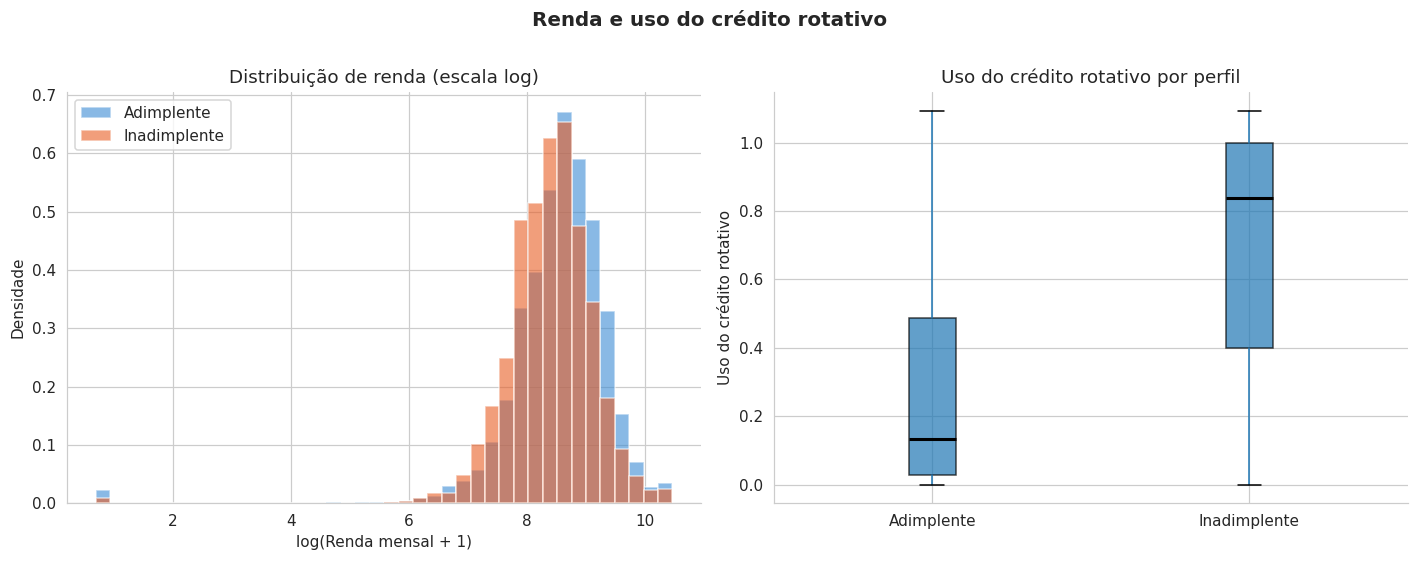

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Distribuição de renda por grupo (escala log) --
ax = axes[0]
for label, grupo, cor in [('Adimplente', adimplentes, COR_ADIMPLENTE),
                            ('Inadimplente', inadimplentes, COR_INADIMPLENTE)]:
    renda_pos = grupo[grupo['renda_mensal'] > 0]['renda_mensal']
    ax.hist(np.log1p(renda_pos), bins=40, alpha=0.6, color=cor, label=label, density=True)
ax.set_xlabel('log(Renda mensal + 1)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição de renda (escala log)')
ax.legend()

# -- Uso do crédito rotativo por grupo --
ax = axes[1]
df.boxplot(column='razao_utilizacao_rotativo', by='target', ax=ax,
           patch_artist=True,
           boxprops=dict(alpha=0.7),
           medianprops=dict(color='black', linewidth=2))
ax.set_xticklabels(['Adimplente', 'Inadimplente'])
ax.set_xlabel('')
ax.set_ylabel('Uso do crédito rotativo')
ax.set_title('Uso do crédito rotativo por perfil')
plt.suptitle('')  # remove título automático do boxplot

plt.suptitle('Renda e uso do crédito rotativo', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figuras/fig_03_renda_credito.png', bbox_inches='tight', dpi=120)
plt.show()

In [26]:
# Comparação de medianas
print('Mediana de renda mensal:')
print(f'  Adimplente:   ${adimplentes["renda_mensal"].median():,.0f}')
print(f'  Inadimplente: ${inadimplentes["renda_mensal"].median():,.0f}')

print('\nMediana de uso do crédito rotativo:')
print(f'  Adimplente:   {adimplentes["razao_utilizacao_rotativo"].median():.3f}')
print(f'  Inadimplente: {inadimplentes["razao_utilizacao_rotativo"].median():.3f}')

Mediana de renda mensal:
  Adimplente:   $5,466
  Inadimplente: $4,500

Mediana de uso do crédito rotativo:
  Adimplente:   0.133
  Inadimplente: 0.839


**💡 Insight de negócio:** Inadimplentes tendem a ter renda menor e uso do crédito rotativo mais alto — ou seja, estão mais próximos (ou além) do limite disponível. Uso acima de 80% do limite pode ser usado como variável de alerta em um sistema de monitoramento de carteira.

---
## Pergunta 4: Quais variáveis têm mais poder preditivo?

Vamos usar a **correlação ponto-bisserial** (adequada para comparar variáveis contínuas com uma variável binária) e um mapa de correlação geral.

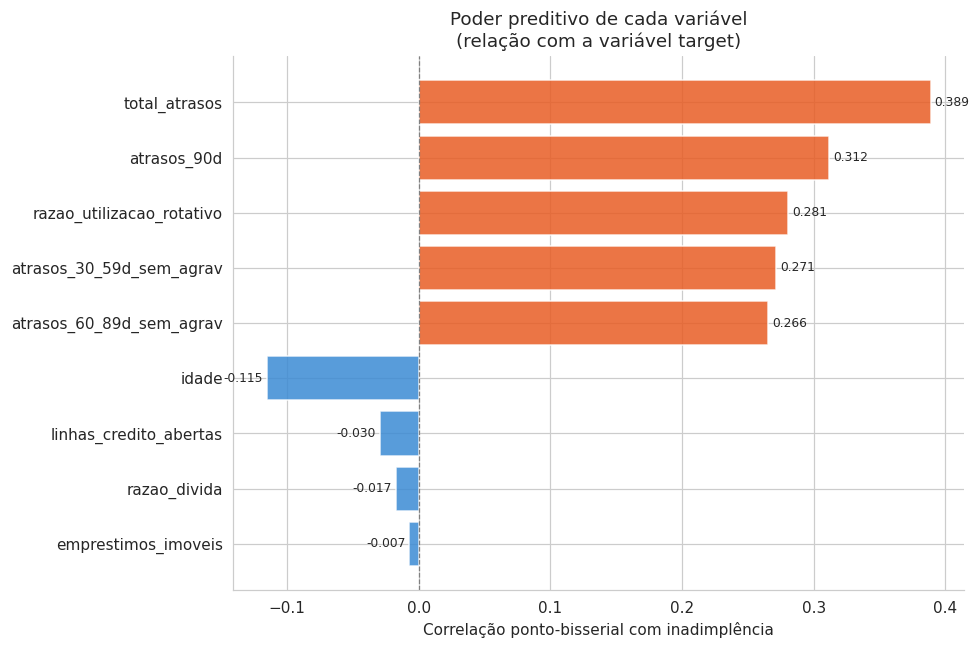

In [27]:
from scipy import stats

colunas_num = ['razao_utilizacao_rotativo', 'idade', 'atrasos_30_59d_sem_agrav', 'razao_divida',
               'renda_mensal', 'linhas_credito_abertas', 'atrasos_90d',
               'emprestimos_imoveis', 'atrasos_60_89d_sem_agrav', 'dependentes',
               'total_atrasos', 'encargos_mensais_estimados']

correlacoes = []
for col in colunas_num:
    r, p = stats.pointbiserialr(df['target'], df[col])
    correlacoes.append({'variavel': col, 'correlacao': r, 'p_valor': p})

df_corr = pd.DataFrame(correlacoes).sort_values('correlacao', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
cores_barras = [COR_INADIMPLENTE if v > 0 else COR_ADIMPLENTE for v in df_corr['correlacao']]
bars = ax.barh(df_corr['variavel'], df_corr['correlacao'], color=cores_barras, alpha=0.85)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Correlação ponto-bisserial com inadimplência')
ax.set_title('Poder preditivo de cada variável\n(relação com a variável target)', fontsize=12)
ax.invert_yaxis()
for bar, val in zip(bars, df_corr['correlacao']):
    xpos = val + 0.003 if val >= 0 else val - 0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.savefig('figuras/fig_04_correlacoes.png', bbox_inches='tight', dpi=120)
plt.show()

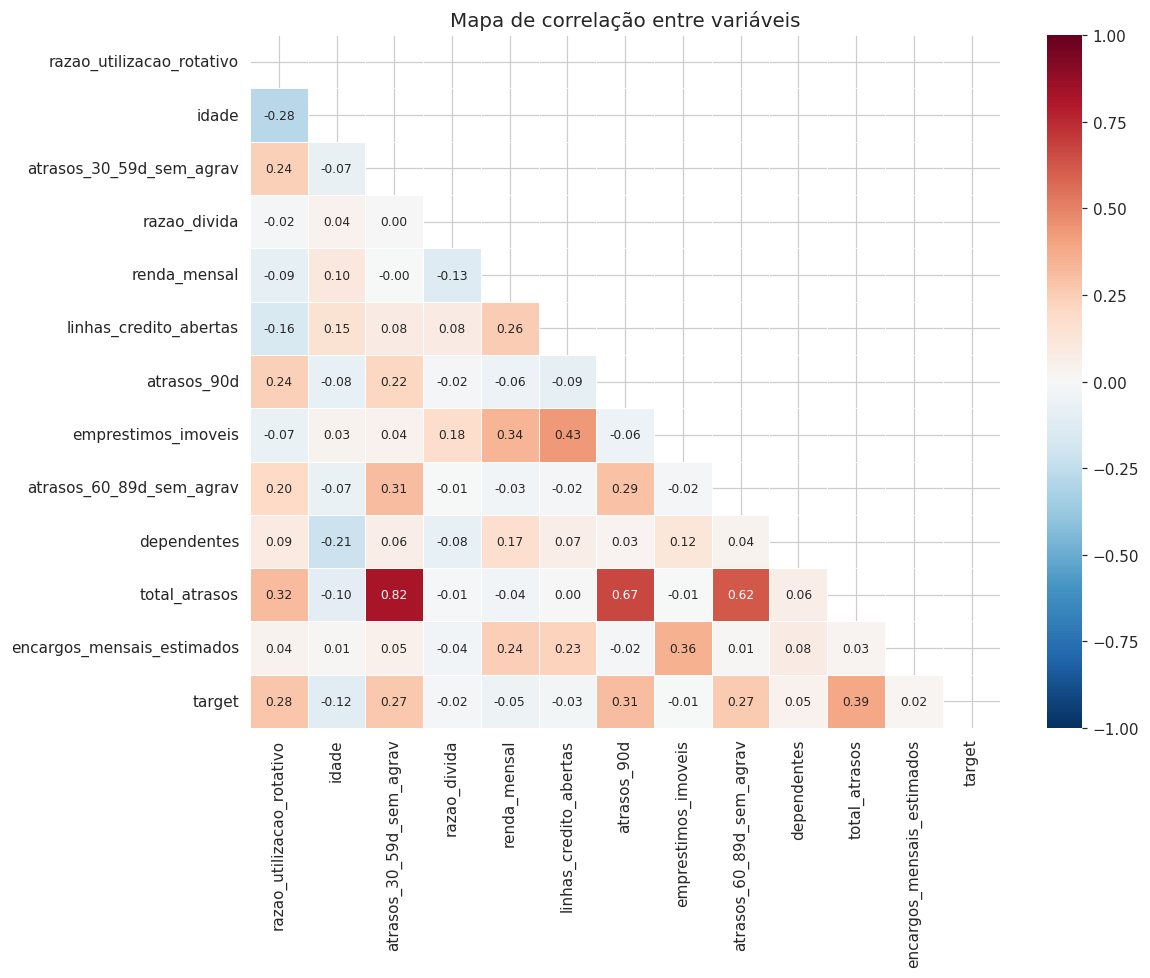

In [28]:
# Mapa de correlação entre todas as variáveis numéricas
fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = df[colunas_num + ['target']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Mapa de correlação entre variáveis', fontsize=13)
plt.tight_layout()
plt.savefig('figuras/fig_05_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

**💡 Insights de negócio:**
- `atrasos_90d`, `total_atrasos` e `atrasos_30_59d_sem_agrav` são as variáveis com maior correlação positiva com inadimplência — **histórico de pagamento é o principal preditor**
- `idade` tem correlação negativa — clientes mais velhos tendem a ser mais adimplentes
- `razao_utilizacao_rotativo` também apresenta correlação relevante — alto uso do limite é um sinal de alerta
- Alta correlação entre as colunas de atraso entre si — normal, pois medem comportamento similar em janelas diferentes

---
## Análise complementar: distribuição do target por faixa de uso do crédito

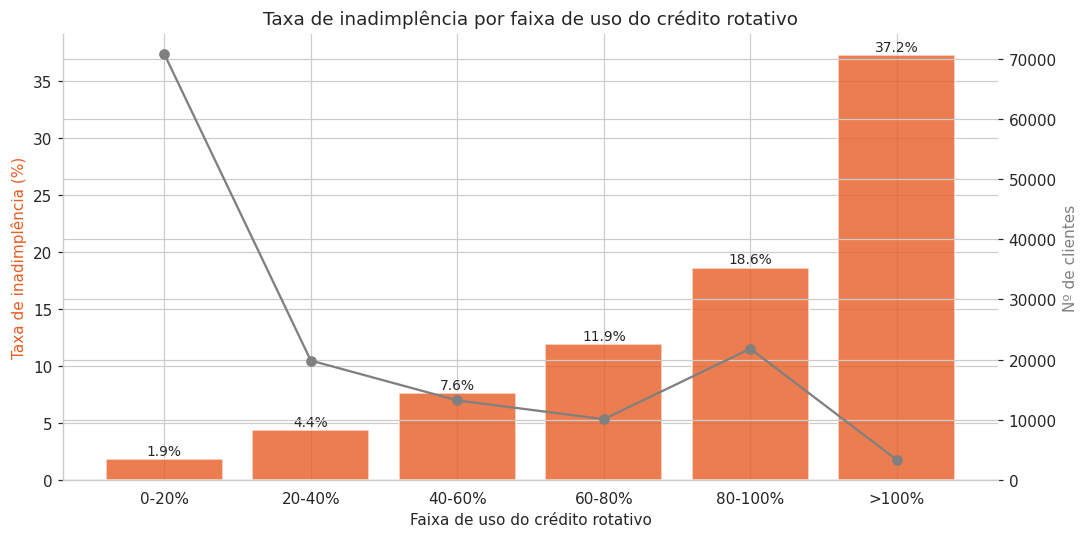

                   taxa_inadimplencia_%  n_clientes
faixa_uso_credito                                  
0-20%                              1.87       70831
20-40%                             4.39       19844
40-60%                             7.60       13216
60-80%                            11.93       10098
80-100%                           18.62       21811
>100%                             37.25        3321


In [29]:
# Dividir uso do crédito em faixas e calcular taxa de inadimplência
df['faixa_uso_credito'] = pd.cut(
    df['razao_utilizacao_rotativo'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0, float('inf')],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100%']
)

taxa_faixa_uso = df.groupby('faixa_uso_credito', observed=True)['target'].agg(['mean', 'count'])
taxa_faixa_uso['mean'] *= 100
taxa_faixa_uso.columns = ['taxa_inadimplencia_%', 'n_clientes']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(taxa_faixa_uso.index, taxa_faixa_uso['taxa_inadimplencia_%'],
               color=COR_INADIMPLENTE, alpha=0.8, label='Taxa de inadimplência')
ax2.plot(taxa_faixa_uso.index, taxa_faixa_uso['n_clientes'],
         color='gray', marker='o', linewidth=1.5, label='Nº de clientes')

ax1.set_xlabel('Faixa de uso do crédito rotativo')
ax1.set_ylabel('Taxa de inadimplência (%)', color=COR_INADIMPLENTE)
ax2.set_ylabel('Nº de clientes', color='gray')
ax1.set_title('Taxa de inadimplência por faixa de uso do crédito rotativo')

for bar, val in zip(bars, taxa_faixa_uso['taxa_inadimplencia_%']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figuras/fig_06_faixa_uso.png', bbox_inches='tight', dpi=120)
plt.show()

print(taxa_faixa_uso)

---
## Síntese dos insights de negócio

| # | Insight | Implicação prática |
|---|---------|--------------------|
| 1 | Jovens (18–35) têm taxa de inadimplência ~2x maior | Políticas de limite diferenciadas para clientes novos |
| 2 | Clientes com histórico de atraso têm risco **Nx** maior | Histórico de pagamento deve ser variável mandatória na análise |
| 3 | `razao_utilizacao_rotativo` >0.8 está associado a maior risco | Monitoramento proativo da carteira ativa |
| 4 | Renda menor está correlacionada com maior inadimplência | Análise de capacidade de pagamento é essencial |
| 5 | As 3 colunas de atraso são altamente correlacionadas entre si | Na modelagem, cuidado com multicolinearidade — considerar usar apenas `total_atrasos` |

> **Próximo passo:** Com esses insights, estamos prontos para construir um modelo preditivo. Já sabemos quais variáveis provavelmente terão mais importância — o modelo vai confirmar (ou surpreender) essas hipóteses.